# Clustering jerarquico

Autores: Pablo Hernández Cámara (pablo.hernandez-camara@uv.es) y Pedro Ramón Ventura Gómez (pventura@march-am.com)



En este notebook exploraremos la conectividad entre datos. A diferencia de K-means, no buscaremos centros, sino relaciones de "parentesco" para construir una estructura de árbol.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs, fetch_openml
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Clustering Jerárquico "A Mano"



Para entender la lógica del proceso, implementaremos el algoritmo básico a mano. El algoritmo aglomerativo (bottom-up) funciona así:

1. Cada punto comienza siendo su propio cluster.

2. Calculamos la matriz de distancias entre todos los clusters.

3. Fusionamos los dos clusters más cercanos.

4. Recalculamos las distancias.

5. Repetir hasta que solo quede un cluster formado por todos los datos.

Primero necesitamos los datos, vamos a generarlos.

In [ ]:
X_mini = np.random.rand(15, 2)
print(X_mini.shape)

(15, 2)


**Ejercicio: Representa los datos. ¿Cuales dirian que van a ser los primeros puntos en unirse?**

Vamos a hacer el algoritmo a mano! Recordad que a diferencia de k-means, no necesitamos definir previamente el número de clusters a encontrar.

In [ ]:
# Inicialmente, cada punto es un cluster
clusters = [[i] for i in range(len(X_mini))]

In [ ]:
for step in range(len(X_mini)):
    min_dist = float('inf')
    pair = (0, 0)

    # Buscamos los dos clusters más cercanos (usando la media de los puntos como centroide temporal)
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            dist = np.linalg.norm(np.mean(X_mini[clusters[i]], axis=0) - np.mean(X_mini[clusters[j]], axis=0))
            if dist < min_dist:
                min_dist = dist
                pair = (i, j)

    # Fusionamos
    c1, c2 = pair
    new_cluster = clusters[c1] + clusters[c2]
    print(f"Paso {step+1}: Fusionando cluster {c1} con {c2}. Nueva comunidad: {new_cluster}")

    if step != len(X_mini)-1:
        clusters.pop(c2)
        clusters.pop(c1)
        clusters.append(new_cluster)

Paso 1: Fusionando cluster 2 con 6. Nueva comunidad: [2, 6]
Paso 2: Fusionando cluster 1 con 2. Nueva comunidad: [1, 3]
Paso 3: Fusionando cluster 9 con 10. Nueva comunidad: [13, 14]
Paso 4: Fusionando cluster 4 con 9. Nueva comunidad: [8, 2, 6]
Paso 5: Fusionando cluster 5 con 8. Nueva comunidad: [10, 1, 3]
Paso 6: Fusionando cluster 2 con 6. Nueva comunidad: [5, 12]
Paso 7: Fusionando cluster 5 con 6. Nueva comunidad: [13, 14, 8, 2, 6]
Paso 8: Fusionando cluster 0 con 5. Nueva comunidad: [0, 10, 1, 3]
Paso 9: Fusionando cluster 1 con 4. Nueva comunidad: [7, 5, 12]
Paso 10: Fusionando cluster 2 con 3. Nueva comunidad: [11, 13, 14, 8, 2, 6]
Paso 11: Fusionando cluster 1 con 2. Nueva comunidad: [9, 0, 10, 1, 3]
Paso 12: Fusionando cluster 0 con 2. Nueva comunidad: [4, 11, 13, 14, 8, 2, 6]
Paso 13: Fusionando cluster 0 con 1. Nueva comunidad: [7, 5, 12, 9, 0, 10, 1, 3]
Paso 14: Fusionando cluster 0 con 1. Nueva comunidad: [4, 11, 13, 14, 8, 2, 6, 7, 5, 12, 9, 0, 10, 1, 3]
Paso 15: Fusion

## Dendograma

El dendrograma es la herramienta visual clave para entender la distancia entre puntos/clusters y como se van uniendo.

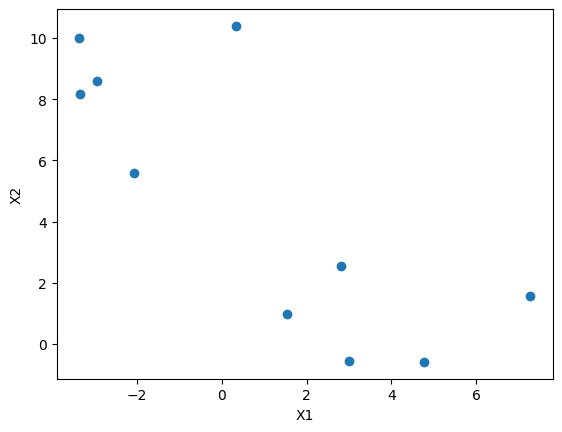

In [ ]:
X, _ = make_blobs(n_samples=10, centers=2, cluster_std=1.8, random_state=42)

plt.scatter(X[:,0], X[:,1])
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Recordad que como definamos la similitud influye mucho en como se van agrupando los datos. Tipos de linkages: simple (min), complete (max), average, median, ward (minimization of variance)...

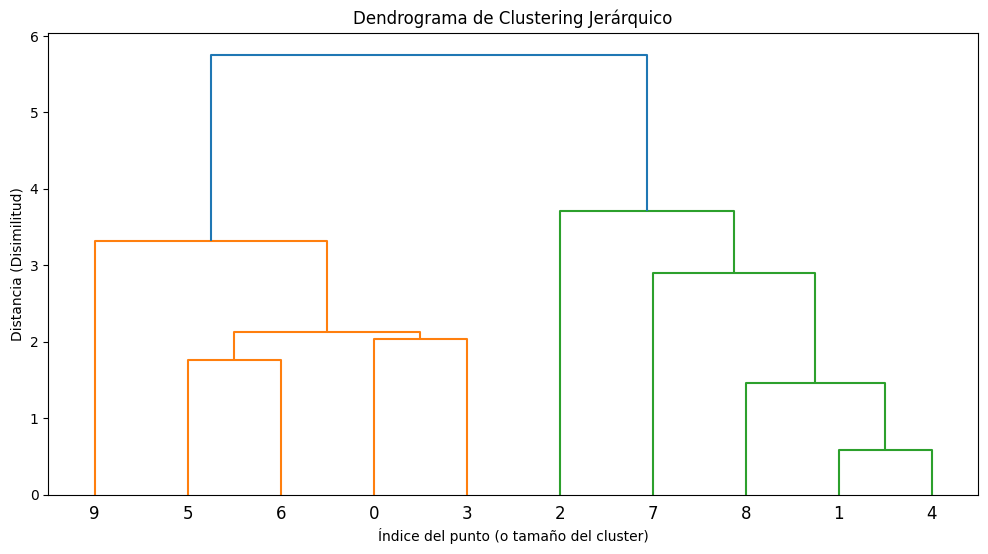

In [ ]:
Z = linkage(X, method='single')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Índice del punto (o tamaño del cluster)')
plt.ylabel('Distancia (Disimilitud)')
plt.show()

**Ejercicio: Comprueba como cambia el dendograma según que medida de similitud/linkage usemos.**

## Hierarchical sklearn

En sklearn es muy facil de usar usando AgglomerativeClustering. Pero vamos a ver como afectan los distintos tipos de linkages al resultado final.

In [ ]:
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=170)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=170)

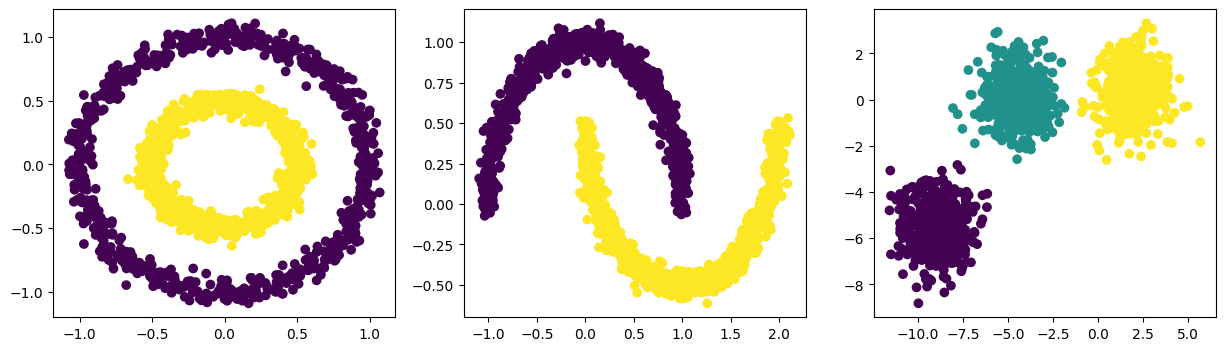

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,4))
ax[0].scatter(noisy_circles[0][:,0], noisy_circles[0][:,1], c=noisy_circles[1])
ax[1].scatter(noisy_moons[0][:,0], noisy_moons[0][:,1], c=noisy_moons[1])
ax[2].scatter(blobs[0][:,0], blobs[0][:,1], c=blobs[1])
plt.show()

**Ejercicio: Aplicar el hierarchical clustering en cada dataset probando single, average, complete and ward linkages en cada caso. Visualiza los resultados.**

## Hierarchical en real data

Vamos a aplicar el algoritmo sobre los componentes principales del dataset German Credit.

In [ ]:
raw_data = fetch_openml(name='credit-g', version=1, as_frame=True)
X_credit = raw_data.data.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_credit)
print(X_scaled.shape)

(1000, 7)


**Ejercicio: Reduce con PCA para mantener las 5 variables más importantes. ¿Cuanta varianza explicas con ellas?**

**Ejercicio: Aplica el AgglomerativeClustering para encontrar 3 clusters usando el single linkage.**

**Ejercicio: Interpreta los grupos.**